## Training the Neural Additive Model (NAM) for correlated nonlinear synthetic data


In [ ]:
import json
from pathlib import Path


best_hp_json = "./hp_tuning_Correlated_nonlinear/best_hp.json"

with open(best_hp_json, 'r') as f:
    best_hp = json.load(f)


# Load fixed training parameters from JSON
fixed_json = "./training_conf/nam_training_parameters_correlated_nonlinear.json"
with open(fixed_json, 'r') as f:
    fixed = json.load(f)

print(f"Loaded fixed training params from: {fixed_json}")



Loaded fixed training params from: ./training_conf/nam_training_parameters_correlated_nonlinear.json


In [2]:
rhos = [0, 0.3, 0.6, 0.8, 0.9, 0.95]
seeds = list(range(20))  # 20 dataset seeds per rho

base_logdir = Path('./correlated_nonlinear')
base_logdir.mkdir(parents=True, exist_ok=True)

skip_if_checkpoint_exists = True
per_run_timeout_s = 3600




In [ ]:
from utils import run_nam_train_sweep

runs, summary_path = run_nam_train_sweep(
    rhos=rhos,
    seeds=seeds,
    fixed=fixed,
    best_hp=best_hp,
    base_logdir=base_logdir,
    skip_if_checkpoint_exists=skip_if_checkpoint_exists,
    per_run_timeout_s=per_run_timeout_s,
)



In [ ]:
import neural_additive_models.data_utils as data_utils
from utils import load_col_min_max, inverse_min_max_scaler

dataset_name = 'Correlated_nonlinear'
correlated_n = 20000
rho = 0
seed = 0
is_regression = True
data =  data_utils.load_dataset(dataset_name, correlated_n, rho, seed)
data_x, data_y, column_names = data
col_min_max = load_col_min_max(dataset_name, correlated_n, rho, seed)

In [5]:
from utils import get_hyperparameter_tuning_indices

fold_train_indices, fold_test_indices = get_hyperparameter_tuning_indices(
    data_x,
    data_y,
    test_size=0.2,
    val_size=0.2,
    is_regression=True,
    random_state=42,  # Must match hp_random_state from training
    combine_train_val=True,  # ← Set to True if combine_train_val_for_final_training=true
)


In [ ]:
from utils import prepare_feature_arrays, get_dataset_config

# Step 1: Prepare data
SINGLE_FEATURES_ORIGINAL, UNIQUE_FEATURES_ORIGINAL, UNIQUE_FEATURES = prepare_feature_arrays(
    data_x, column_names, col_min_max, inverse_min_max_scaler
)

# Step 2: Load dataset-specific config
COL_NAMES, FEATURE_LABEL_MAPPING, CATEGORICAL_NAMES = get_dataset_config(dataset_name, column_names)

Processing seed 0...
Using checkpoint: ./correlated_nonlinear/rho_03/seed_0/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1040
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from ./correlated_nonlinear/rho_03/seed_0/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1040
✅ Restored NAM from checkpoint.
Using checkpoint: ./correlated_nonlinear/rho_03/seed_1/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1820
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from ./correlated_nonlinear/rho_03/seed_1/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1820
✅ Restored NAM from checkpoint.
Using checkpoint: ./correlated_nonlinear/rho_03/seed_2/fold_1/split_1/model_0/best_checkpoint\model.ckpt-3120
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from ./cor

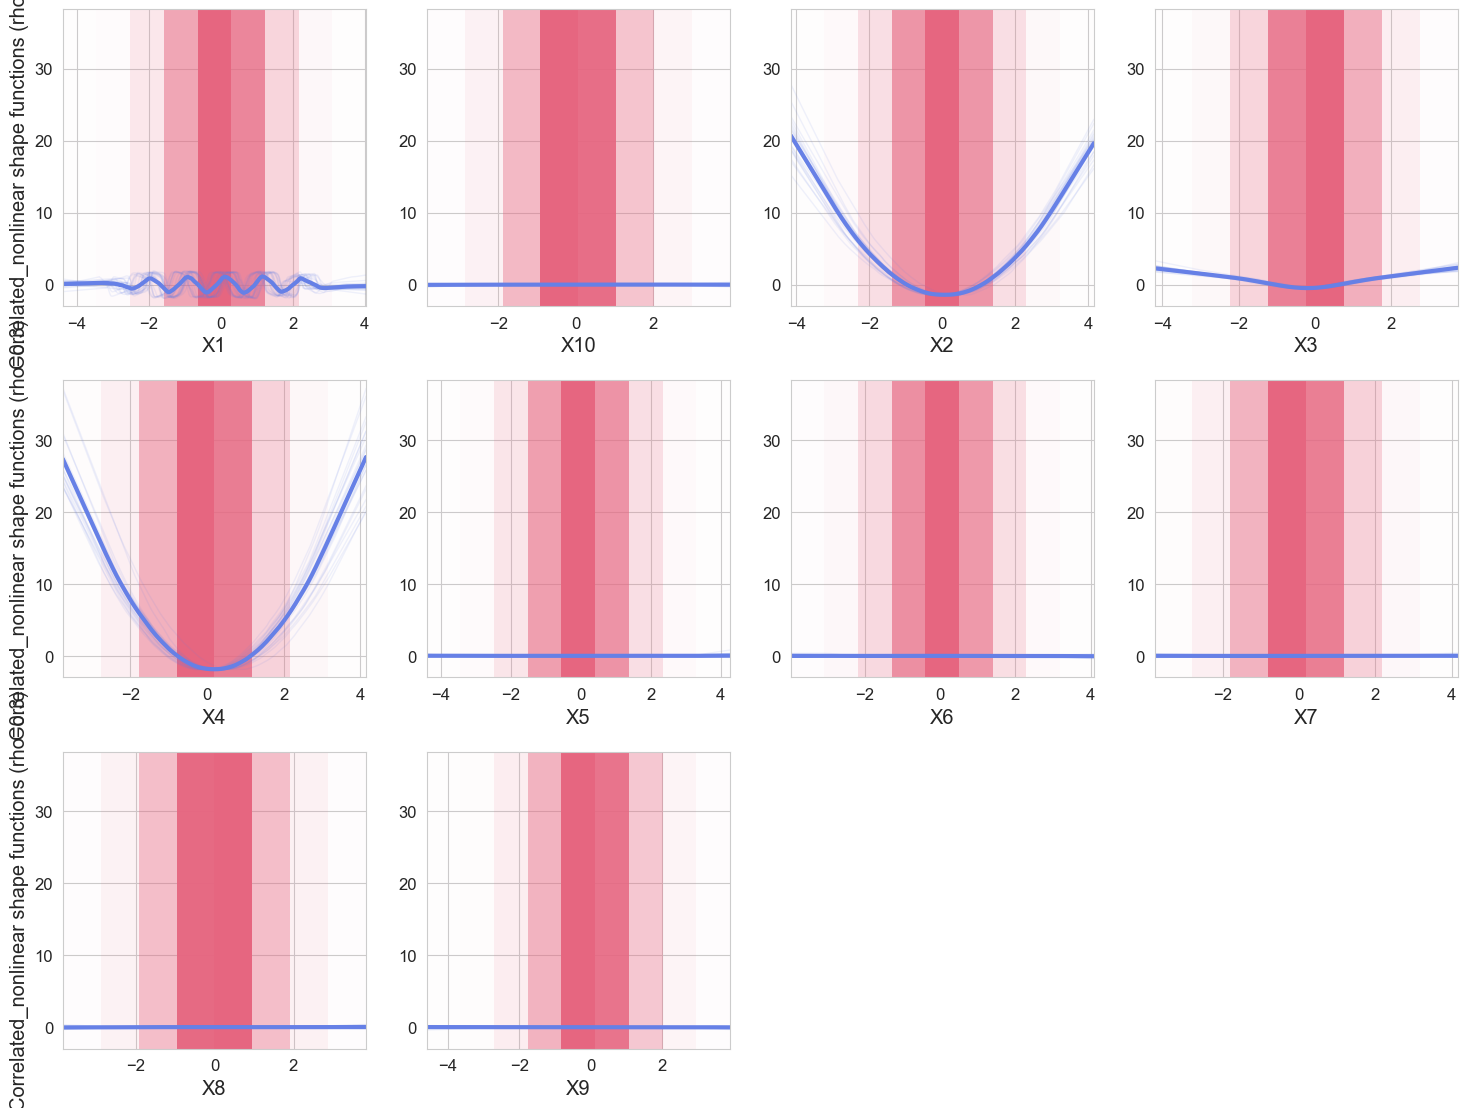

In [ ]:
from utils import analyze_correlated_shape_functions, plot_nam_contributions_with_density

dataset_name = "Correlated_nonlinear"
rho = 0
seeds = list(range(20))

(
    seed_rmses,
    all_hist_data,
    all_mean_pred,
    UNIQUE_FEATURES_ORIGINAL,
    SINGLE_FEATURES_ORIGINAL,
    column_names,
) = analyze_correlated_shape_functions(
    dataset_name=dataset_name,
    rho=rho,
    seeds=seeds,
    fixed=fixed,
    best_hp=best_hp,
    fold_num_trained=1,
    n_folds=2,
    split_num_trained=1,
    random_state=42,
    n_grid=400,
    ckpt_base_dir=None,
    print_every=5,
)

col_mapping = {c: c for c in column_names}
feature_mapping = {}
categorical_names = []

fig = plot_nam_contributions_with_density(
    hist_data=all_hist_data,
    unique_features=UNIQUE_FEATURES_ORIGINAL,
    single_features=SINGLE_FEATURES_ORIGINAL,
    categorical_names=categorical_names,
    col_mapping=col_mapping,
    feature_mapping=feature_mapping,
    mean_pred=all_mean_pred,
    feature_to_use=column_names,
    dataset_label=f"{dataset_name} shape functions (rho={rho})",
)


In [7]:
from utils import evaluate_correlated_models

(rmse_by_rho_seed, rmse_df, summary, rho_rmses), (shape_df, shape_by_rho_seed_feature) = evaluate_correlated_models(
    dataset_name="Correlated_nonlinear",
    rhos=rhos,
    seeds=seeds,
    fixed=fixed,
    best_hp=best_hp,
    compute_shape_rmse=True
)

Using checkpoint: ./correlated_nonlinear/rho_0/seed_0/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1430
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from ./correlated_nonlinear/rho_0/seed_0/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1430
✅ Restored NAM from checkpoint.
Using checkpoint: ./correlated_nonlinear/rho_0/seed_1/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1560
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from ./correlated_nonlinear/rho_0/seed_1/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1560
✅ Restored NAM from checkpoint.
Using checkpoint: ./correlated_nonlinear/rho_0/seed_2/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1950
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from ./correlated_nonlinear/rho_0/se

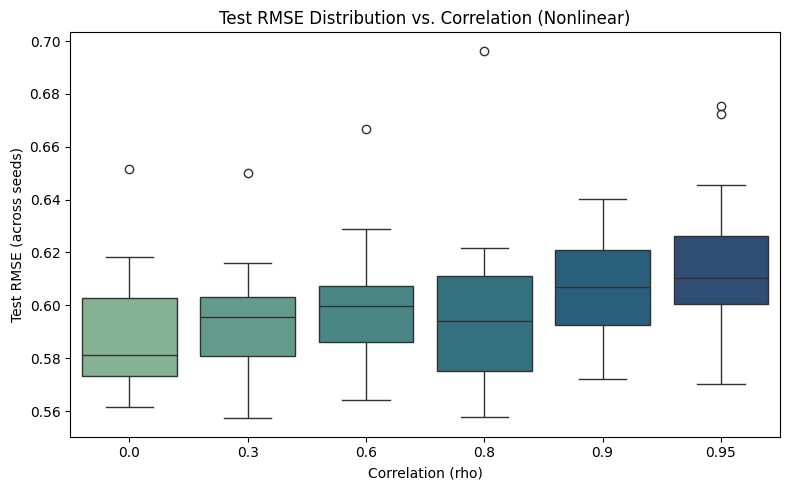

In [8]:
from utils import plot_rmse_boxplot_vs_rho

plot_rmse_boxplot_vs_rho(rmse_df, dataset_label="Nonlinear")



Shape RMSE Statistics:
   Overall mean: 2.3068
   Overall std: 3.9926
   Min: 0.0059
   Max: 16.6857

Per-feature average shape RMSE (mean ± std):
   X9: 0.0454 ± 0.0281
   X7: 0.0488 ± 0.0365
   X5: 0.0504 ± 0.0279
   X10: 0.0509 ± 0.0310
   X8: 0.0555 ± 0.0343
   X6: 0.0559 ± 0.0349
   X3: 1.1633 ± 0.3186
   X1: 1.7752 ± 0.1395
   X2: 7.9538 ± 1.0839
   X4: 11.8691 ± 1.6002


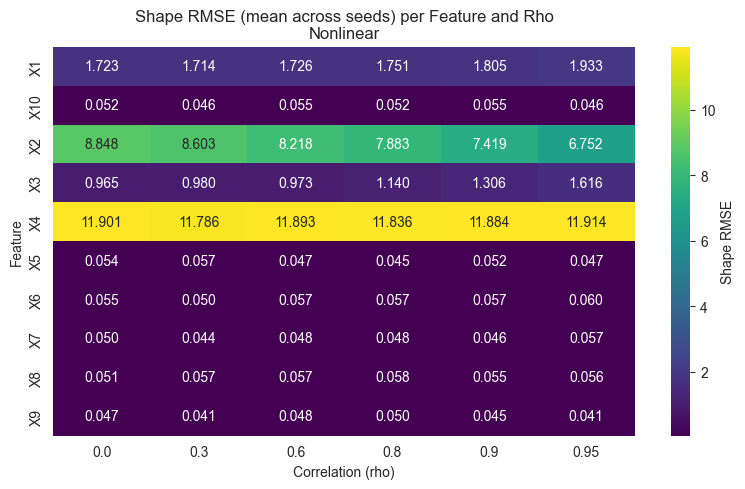

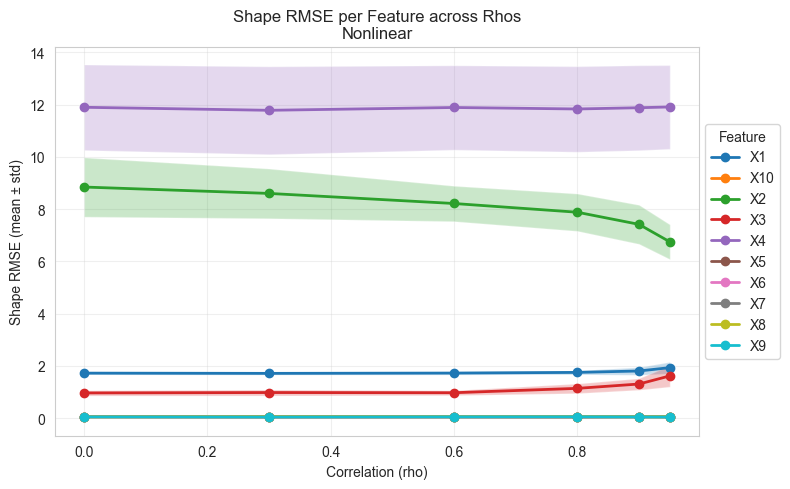

In [9]:
from utils import analyze_shape_rmse

analyze_shape_rmse(shape_df, dataset_label="Nonlinear")
